# 3.2 Substructure and planetesimal formation

In this complex example we want to add planets to our simulation which are opening gaps in the gas disk. Additionally, we want to add planetesimal formation triggered by the accumulation of dust in the outer edges of the gaps.

Here we are utilizing [DustPyLib](https://dustpylib.readthedocs.io/en/latest/) which is a library of DustPy extensions ready to be used in simulations.

We start as usual by creating and initializing a new DustPy simulation frame.

In [1]:
from dustpy import Simulation

In [2]:
sim = Simulation()

In this simulation we want to increase the fragmentation velocity from $1\,\mathrm{\frac{m}{s}}$ to $10\,\mathrm{\frac{m}{s}}$ to facilitate planetesimal formation.

In [3]:
sim.ini.dust.vFrag = 1000.

Due to the larger particle sizes we also want to extend the mass grid by three orders of magnitude, i.e. the particle size grid by one order of magnitude.

In [4]:
sim.ini.grid.mmax *= 1.e3

## Adding planets

In the next step we are adding planets to the simulation. In this example we want to add Jupiter and Saturn at their current locations.  
We utilize a SimpleNamespace to help us setting up any number of planets. For all planets we need their mass and their semimajor axis.

In [5]:
from dustpy import constants as c
from simframe.utils import SimpleNamespace

In [6]:
planets = {
    "jupiter": SimpleNamespace(**{
        "a": 5.2 * c.au,
        "M": 1.0 * c.M_jup,
    }),
    "saturn": SimpleNamespace(**{
        "a": 9.6 * c.au,
        "M": 95. * c.M_earth,
    }),
}
planets = SimpleNamespace(**planets)

`planets` is now a nested namespace that can be used to easily access the planet parameters.

In [7]:
planets

namespace(jupiter=namespace(a=77790892764000.0, M=1.8981245973360504e+30),
          saturn=namespace(a=143613955872000.0, M=5.67355947440181e+29))

Now we add a group for the planets to the DustPy simulation frame.

In [8]:
sim.addgroup("planets", description="Planetary quantities");

In [9]:
sim

DustPy
------
    dust         : Group (Dust quantities)
    gas          : Group (Gas quantities)
    grid         : Group (Grid quantities)
    planets      : Group (Planetary quantities)
    star         : Group (Stellar quantities)
  -----
    t            : NoneType
  -----
    Integrator   : not specified
    Writer       : not specified

And then we iterate over the planets in our namespace and create a subgroup for each storing their parameters.

In [10]:
for name, planet in planets:
    group = sim.planets.addgroup(name);
    group.addfield("M", planet.M, description="Planetary Mass [g]");
    group.addfield("a", planet.a, description="Semi-major axis [cm]");

We have now loaded our planets into the simulation object...

In [11]:
sim.planets

Group (Planetary quantities)
----------------------------
    jupiter      : Group
    saturn       : Group
  -----

...and we can access their parameters in the usual way.

In [12]:
sim.planets.jupiter.a / c.au

5.2

## Refining the grid

We want to refine the grid at the planet location to have a higher resolution in the planetesimal formation region.  
For this we utilize a submodule of DustPyLib.

In [13]:
from dustpylib.grid.refinement import refine_radial_local

This function refines the grid by recursively placing new grid cell interfeaces in between two existing interfaces. We, therefore, need an existing grid to start with.

In [14]:
import numpy as np

In [15]:
ri = np.geomspace(sim.ini.grid.rmin, sim.ini.grid.rmax, sim.ini.grid.Nr+1)

We now refine this existing grid at out planet locations.

In [16]:
for name, planet in sim.planets:
    ri = refine_radial_local(ri, 1.45*planet.a, num=3)

We assign this new grid to the grid cell interfaces of DustPy.

In [17]:
sim.grid.ri = ri

In [18]:
sim.initialize()

DustPy now initialized the simulation frame on our newly defined grid as is evident by the increased number of radial grid cells.

In [19]:
sim.grid.Nr

118

## Gap opening by planets

We use the gap openin prescription used in [Lau et al. (2025)](). Here a torque applied to the gas is opening gaps according to the gap profiles by [Duffell (2020)](https://doi.org/10.3847/1538-4357/ab5b0f).

The torque that need to be applied is given by

$\Large \Lambda = -\frac{3}{2}\nu\Omega_\mathrm{K}\left(\frac{1}{2f}-\frac{\partial\log f}{\partial\log r}-\frac{1}{2}\right)$

where $f$ is the desired gap shape defined as

$\Large f = \frac{\Sigma\left(r\right)}{\Sigma_0}$

We can get the gap shapes from DustPyLib.

In [20]:
from dustpylib.substructures.gaps import duffell2020

Our task is now to create a function that is returning this $\Lambda$ profile.

In [21]:
from scipy.interpolate import interp1d

In [22]:
def Lambda(sim, return_profile=False):
    """
    Function computes the torque profile needed to open gaps by planets.

    The function has an additional keyword argument `return_profile` that
    allows us to return the gap profiles in addition of the torque.
    """
    # These are the gap profiles at the grid cell centers and interfaces needed
    # to compute the gradient. They are initialized with 1, meaning no gaps.
    f = np.ones(sim.grid.Nr)
    fi = np.ones(sim.grid.Nr+1)

    # Here we iterate over the planets in our simulation.
    for name, planet in sim.planets:
        # The Duffell (2020) profiles need the planet-to-star mass ratio,
        # the aspect ratio and the alpha viscosity parameter at the
        # planet location. We need to interpolate for that.
        q = planet.M/sim.star.M
        _h = interp1d(sim.grid.r, sim.gas.Hp/sim.grid.r)
        h = _h(planet.a)
        _alpha = interp1d(sim.grid.r, sim.gas.alpha)
        alpha = _alpha(planet.a)
        # Here we use DustPyLib to get the gap profiles
        f *= duffell2020(sim.grid.r, planet.a, q, h, alpha)
        fi *= duffell2020(sim.grid.ri, planet.a, q, h, alpha)
    # This is the logarithmic gradient of the gap profile
    grad = np.diff(np.log10(fi))/np.diff(np.log10(sim.grid.ri))
    # The torque profile.
    ret = -1.5 * sim.gas.nu * sim.grid.OmegaK * (0.5/f - grad - 0.5)
    # If requested return torque and gap profile (not compatible with DustPy)
    if return_profile:
        return ret, f
    # Only return torque for DustPy
    return ret

This function needs to be loaded into the updater of the torque.

In [23]:
sim.gas.torque.Lambda.updater = Lambda

Since we have written the function in this way, we can plot the gap profiles this torque should create.

In [24]:
import matplotlib.pyplot as plt
plt.rcParams["figure.dpi"] = 150.

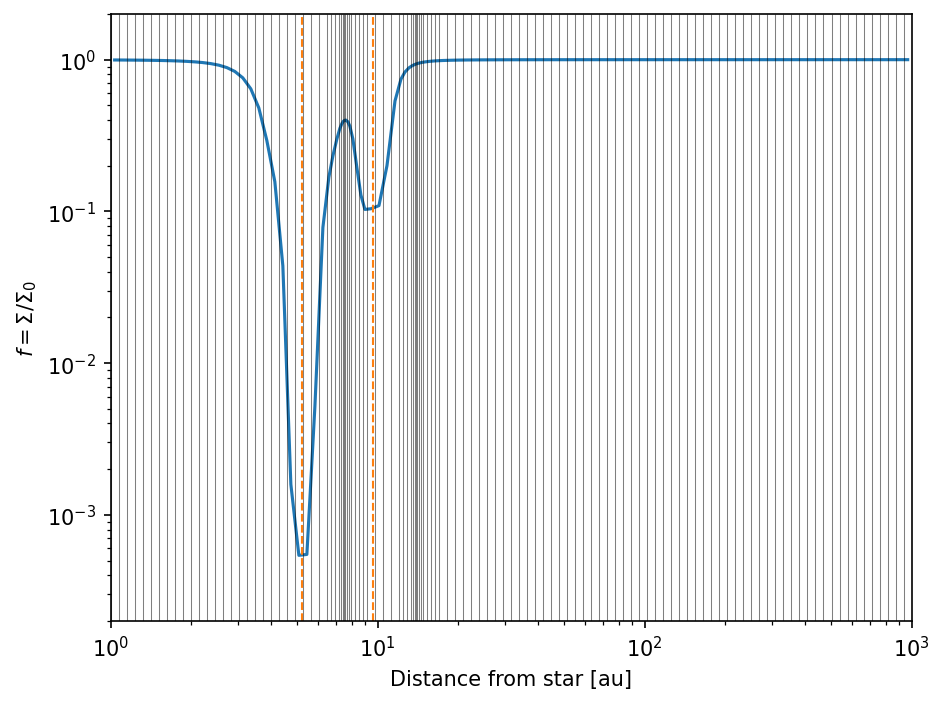

In [25]:
fig, ax = plt.subplots()
ax.plot(sim.grid.r/c.au, Lambda(sim, return_profile=True)[1])
ax.vlines(sim.grid.ri/c.au, 2.e-4, 2.e0, lw=0.5, color="black", alpha=0.5)
for name, p in sim.planets:
    ax.axvline(p.a/c.au, ls="--", color="C1", lw=1)
ax.set(
    xscale="log", xlabel="Distance from star [au]", ylim=[2.e-4, 2.e0],
    yscale="log", ylabel=r"$f = \Sigma / \Sigma_0$", xlim=[sim.grid.ri[0]/c.au, sim.grid.ri[-1]/c.au], 
)
fig.set_layout_engine("tight")

In this plot we can additionally see that we have refined our grid approximately in the region of the pressure maxima outside of the gaps.

## Adding planetesimal formation

In the next step we include planetesimal formation. DustPyLib provides different flavors of [planetesimal formation prescriptions](https://dustpylib.readthedocs.io/en/latest/planetesimal_formation.html). For this example we chose the prescription of [Miller et al. (2021)](https://doi.org/10.1093/mnras/stab2935).

If the criterion of planet formation is fulfilled, we transform a fraction of $\zeta$ of the dust mass per dust settling timescale into planetesimals

$\Large \frac{\partial \Sigma_i}{\partial t} = - \zeta \frac{\Sigma_i}{t_\mathrm{sett}} = -\zeta \Sigma_i \mathrm{St}_i \Omega_\mathrm{K}$.

The probability that planetesimal formation is active is given by a sharp transition function centered on a critical midplane dust-to-gas ratio $\epsilon$ smeared out by a smooting factor $n$

$\Large \mathcal{P} = \frac{1}{2} \left[ 1 + \tanh \left( \frac{\log \epsilon - \log \epsilon_\mathrm{crit}}{n} \right) \right]$.

We, therefore have to define three parameters

In [26]:
eps  = 1.     # critical midplane dust-to-gas ratio of planetesimal formation
n    = 0.03   # Smoothing parameters
zeta = 1.e-1  # Planetesimal formation efficiency

Planetesimal formation means we have to remove mass from the dust. Therefore, we need to write a function that computes the dust loss rate, for which we can utilize DustPyLib.

In [27]:
from dustpylib.planetesimals.formation import miller2021

In [28]:
def Sext(sim):
    """
    Function computes the dust loss terms due to planetesimal formation
    using the prescription of Miller et al. (2021).
    """
    return miller2021(
        sim.grid.OmegaK,
        sim.dust.rho,
        sim.gas.rho,
        sim.dust.Sigma,
        sim.dust.St,
        d2g_crit=eps,
        n=n,
        zeta=zeta
    )

We have to tell DustPy to use this function as additional external source function for the dust.

In [29]:
sim.dust.S.ext.updater = Sext

But we do not only want to remove mass from the dust, we also want to add this mass to planetesimals. Therefore, we need to create a new group for the planetesimals and add a field for the planetesimal surface density.

In [30]:
sim.addgroup("planetesimals", description="Planetesimal quantities");
sim.planetesimals.addfield("Sigma", np.zeros_like(sim.gas.Sigma), description="Surface density [g/cm²]");

The mass that is removed from the dust has to be added to the planetesimals. We, therefore, integrate the planetesimal surface density. To integrate a field we need to write a function, that is returning the derivative of a field. In our case this is simply the negative sum of the dust source terms. The function additionally needs the current time and the current value of the field as argument.

In [31]:
def dSigmaPlanetesimals_dt(sim, t, Sigma_planetesimals):
    """
    Function computes the time derivative of the planetesimal surface density.
    This is simply the negative sum of the external dust source terms.
    """
    return -sim.dust.S.ext.sum(-1)

We have to add this function to the differentiator of the planetesimal surface density.

In [32]:
sim.planetesimals.Sigma.differentiator = dSigmaPlanetesimals_dt

Next we have to tell DustPy to integrate this field. This means if have to add an integration instruction. In this example we use a simple 1st order explicit Euler scheme.

In [33]:
from simframe import Instruction
from simframe import schemes

In [34]:
sim.integrator.instructions.append(
    Instruction(schemes.expl_1_euler, sim.planetesimals.Sigma, description="Planetesimals: explicit 1st-order Euler")
)

In [35]:
sim.integrator.instructions

[Instruction (Dust: implicit 1st-order direct solver),
 Instruction (Gas: implicit 1st-order direct solver),
 Instruction (Planetesimals: explicit 1st-order Euler)]

We are now ready to go. Before starting the simulation we want to extend the simulation beyond the default $100\,000$ years.

In [36]:
sim.t.snapshots = np.concatenate(
    (
        [0.],
        np.geomspace(1.e3, 1.e6, 31) * c.year
    )
)

We want to change the default data directory and let Simframe overwrite existing data files.

In [37]:
sim.writer.datadir = "3.2_substructure_planetesimal_formation"
sim.writer.overwrite = True

In [ ]:
sim.run()


DustPy v1.0.9

Documentation: https://stammler.github.io/dustpy/
PyPI:          https://pypi.org/project/dustpy/
GitHub:        https://github.com/stammler/dustpy/

Please cite Stammler & Birnstiel (2022).

Checking for mass conservation...

    - Sticking:
        max. rel. error:  2.81e-14
        for particle collision
            m[114] =  1.93e+04 g    with
            m[116] =  3.73e+04 g
    - Full fragmentation:
        max. rel. error:  6.66e-16
        for particle collision
            m[90] =  7.20e+00 g    with
            m[95] =  3.73e+01 g
    - Erosion:
        max. rel. error:  1.78e-15
        for particle collision
            m[110] =  5.18e+03 g    with
            m[118] =  7.20e+04 g

Writing file 3.2_substructure_planetesimal_formation/data0000.hdf5
Writing dump file 3.2_substructure_planetesimal_formation/frame.dmp
